# Project 2: Student Exam Performance

## Scenario
This dataset show the student-related academic, lifestyle, and socio-enconmic factores that include exam perdormance. It include study hours, student attendence, sleep hours, motivation, tutoring sessions, parental involvement, school type and other environmental features. The main target varibale is Exam_Score which represents the student final exam score.

## Objective
This notebook is to Explore the Student Academic dataset and discover relationships and state some assumption and try to prove them, and note my discoveries

## Approach
Apply EDA to explore the data, gather assumptions, and verify my assumption using statistical tests

## **Code Setup**

In [1]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Paths
DATA_PATH = Path('../data/raw/')
OUTPUT_PATH = Path('../output/')

#Stats
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

ALPHA=0.05

## **Data Loading And validation**


In [2]:
df = pd.read_csv(str(DATA_PATH) + '/StudentPerformanceFactors.csv')
print("Data Loaded\n")

print(f'Shape: {df.shape}\n')

print(f'Columns:\n {df.info()}\n')

df.head(5)


Data Loaded

Shape: (6607, 20)

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null 

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


# **EDA**
Here we will create assumptions and check those assumptions with **visualizations** and **Hypothesis Testing**

## Exploring and Check distribution of the data:

Text(1.6944444444444375, 0.5, 'Density')

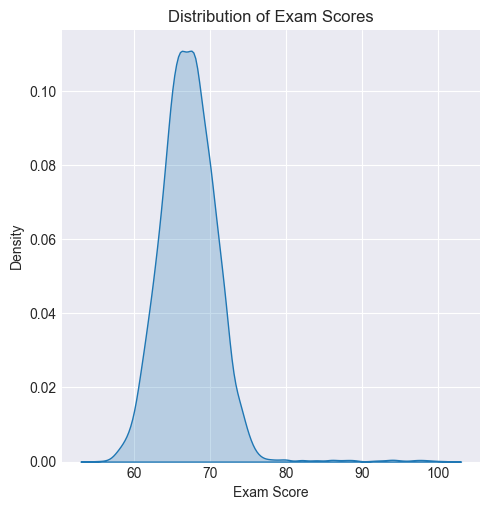

In [4]:
sns.displot(data=df, x='Exam_Score', kind='kde', fill='True')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Density')

Text(0.5, 0, 'Exam Score')

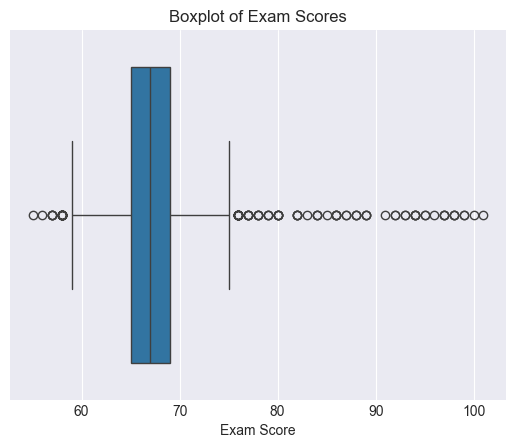

In [5]:
sns.boxplot(data=df, x='Exam_Score')
plt.title('Boxplot of Exam Scores')
plt.xlabel('Exam Score')

In [6]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

---


## Q1: More studied hours lead to better exam scores? 

Here i am going to use `sns.regplot` which is just a scatter plot with a regression line to better see the relationship

Text(0, 0.5, 'Exam Score')

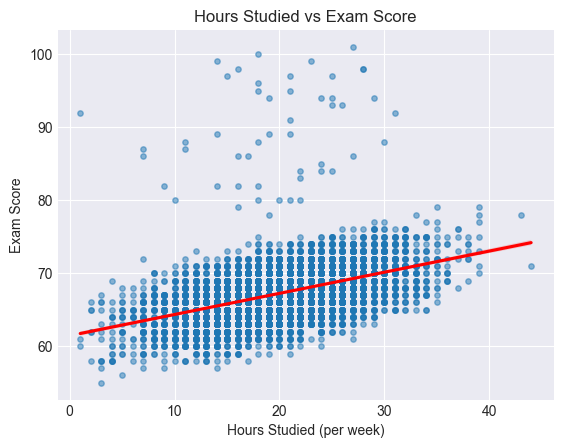

In [ ]:
sns.regplot(data=df, x='Hours_Studied', y='Exam_Score', scatter_kws={'s': 15, 'alpha': 0.5}, line_kws={'color': 'red'})

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied (per week)')
plt.ylabel('Exam Score')

As we can see here from the viz Students with higher studying hours --> higher exam socre on average 

but we need to do Hypothesis testing to prove that there is a relation 

we will use pearson correlation to do it 

`H0` There is no relationship between Hours Studied and Exam scores

`H1` There is a relationship between Hours Studied and Exam Scores

In [8]:
r,p = stats.pearsonr(df['Hours_Studied'],y=df['Exam_Score'])

print(f'r={r}\nP-value: {p:.10f}')
if p < ALPHA:
    print(f'We Reject H0: There is relationship between Hours Studied and Exam scores')
else:
    print("We do not reject H0: There is no relationship between Hours Studied and Exam scores")
    


r=0.4454549540752818
P-value: 0.0000000000
We Reject H0: There is relationship between Hours Studied and Exam scores


**Insight**: Based on the data There is a moderate possitive relationship `r=0.44` between `Hours_Studied` and `exam_scores` 

---


## Q2: Do people with less parental involvment tend to have less atendance?

since we are comparing different groups `sns.boxplot` would be suitable 

Text(0, 0.5, 'Attendance (%)')

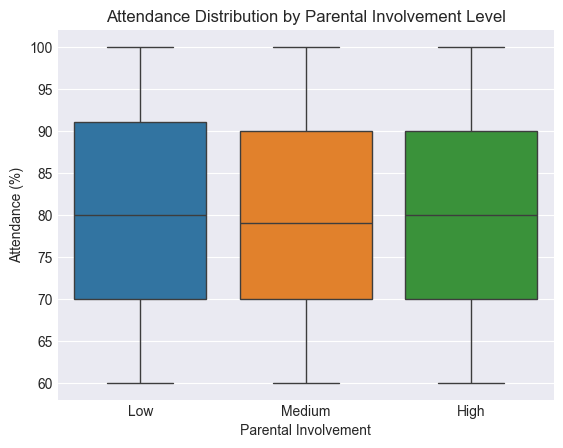

In [9]:
df['Parental_Involvement'].value_counts()

sns.boxplot(data=df, x='Parental_Involvement', y='Attendance', hue='Parental_Involvement')
plt.title('Attendance Distribution by Parental Involvement Level')
plt.xlabel('Parental Involvement')
plt.ylabel('Attendance (%)')

From what i interpret from the viz there is no relationship between `Parental_Involvement` and `Attendance`

but we have to statistically check it using Hypothesis testing 

`H0` There is no relationship between Parental Involvement and attendance

`H1` There a relationship between Involvement and attendance

In [10]:
tukey = pairwise_tukeyhsd(endog=df['Attendance'],
                          groups=df['Parental_Involvement'],
                          alpha=ALPHA)

print(tukey)
print("significant! we reject H0" if (tukey.reject.any()) else "not enough evidence, We fail to reject H0")


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  High    Low    0.357 0.6612 -0.6085 1.3226  False
  High Medium  -0.0843 0.9648 -0.8603 0.6916  False
   Low Medium  -0.4414 0.4639 -1.3167 0.4339  False
---------------------------------------------------
not enough evidence, We fail to reject H0


**Insight**: There is no significant relationship between `Parental_Involvement` and `Attendance`

---

## Q3 Students with ess sleep hours tend to study more?

Text(0, 0.5, 'Hours Studied (per week)')

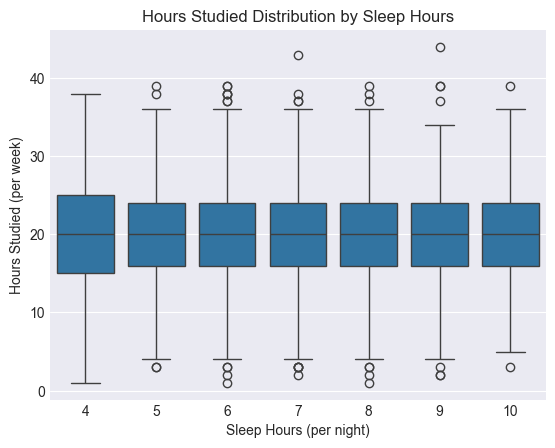

In [11]:
sns.boxplot(data=df, x='Sleep_Hours', y='Hours_Studied')
plt.title('Hours Studied Distribution by Sleep Hours')
plt.xlabel('Sleep Hours (per night)')
plt.ylabel('Hours Studied (per week)')

From what i interpret from the viz there is no relationship between `Sleep_Hours` and `Hours_Studied`

but we have to statistically check it using Hypothesis testing 

`H0` There is no relationship between Sleep Hours and Hours Studied

`H1` There a relationship between Sleep Hours and Hours Studied

In [12]:
r,p = stats.pearsonr(df['Hours_Studied'],y=df['Sleep_Hours'])

print(f'r={r}\nP-value: {p:.10f}')
if p < ALPHA:
    print(f'We Reject H0: There is relationship between Hours Studied and Sleep Hours')
else:
    print("We do not reject H0: There is no relationship between Hours Studied and Sleep_Hours")
    


r=0.010976689296114315
P-value: 0.3723493670
We do not reject H0: There is no relationship between Hours Studied and Sleep_Hours


**Insight**: There is no relationship between `Hours_Studied` and `Sleep_Hours`

---

## Q4: Students with better teachers tend to have better exam scores?

I noticed before that `Teacher_quality` has missing values so i need to drop rows with null values

Text(0, 0.5, 'Exam Score')

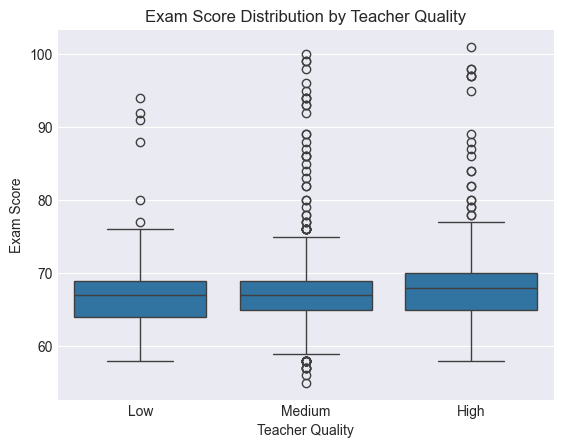

In [13]:
df_q4 = df.dropna(subset=['Teacher_Quality', 'Exam_Score'])

sns.boxplot(data=df_q4, x='Teacher_Quality', y='Exam_Score', order=['Low', 'Medium', 'High'])
plt.title('Exam Score Distribution by Teacher Quality')
plt.xlabel('Teacher Quality')
plt.ylabel('Exam Score')

**Interpretation**: From what i see in the viz boxes looks very similar but the High teacher quality has a median a bit above the others

`H0` There is no relationship between Teacher Quality and Exam Scores

`H1` There a relationship between Teacher Quality and Exam Scores

In [14]:
tukey = pairwise_tukeyhsd(endog=df_q4['Exam_Score'],
                          groups=df_q4['Teacher_Quality'],
                          alpha=ALPHA)

print(tukey)
print("significant! we reject H0" if (tukey.reject.any()) else "not enough evidence, We fail to reject H0")


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low  -0.9235    0.0 -1.3349 -0.5121   True
  High Medium  -0.5676    0.0 -0.8204 -0.3149   True
   Low Medium   0.3559 0.0764 -0.0285  0.7402  False
----------------------------------------------------
significant! we reject H0


                                                                                                                        
  - High vs Low: significant (p=0.0), High scores ~0.92 more 
                                                               
  - High vs Medium: significant (p=0.0), High scores ~0.57 more                                                           

  - Low vs Medium: NOT significant (p=0.076), no real difference  

  **Insight:** statistically significant but the actual difference is very small (~1 point), so teacher quality has minimal practical impact on scores.

  ---

## Q5: Does higher physical activity increase motivation levels?

First we check the distribution of Physical activity 

Text(0, 0.5, 'Count')

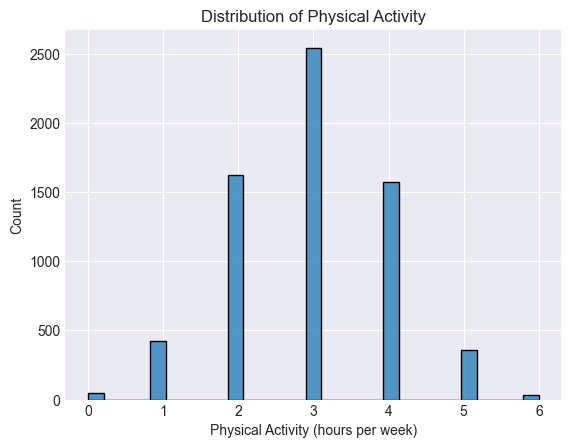

In [15]:
sns.histplot(data=df, x='Physical_Activity')
plt.title('Distribution of Physical Activity')
plt.xlabel('Physical Activity (hours per week)')
plt.ylabel('Count')

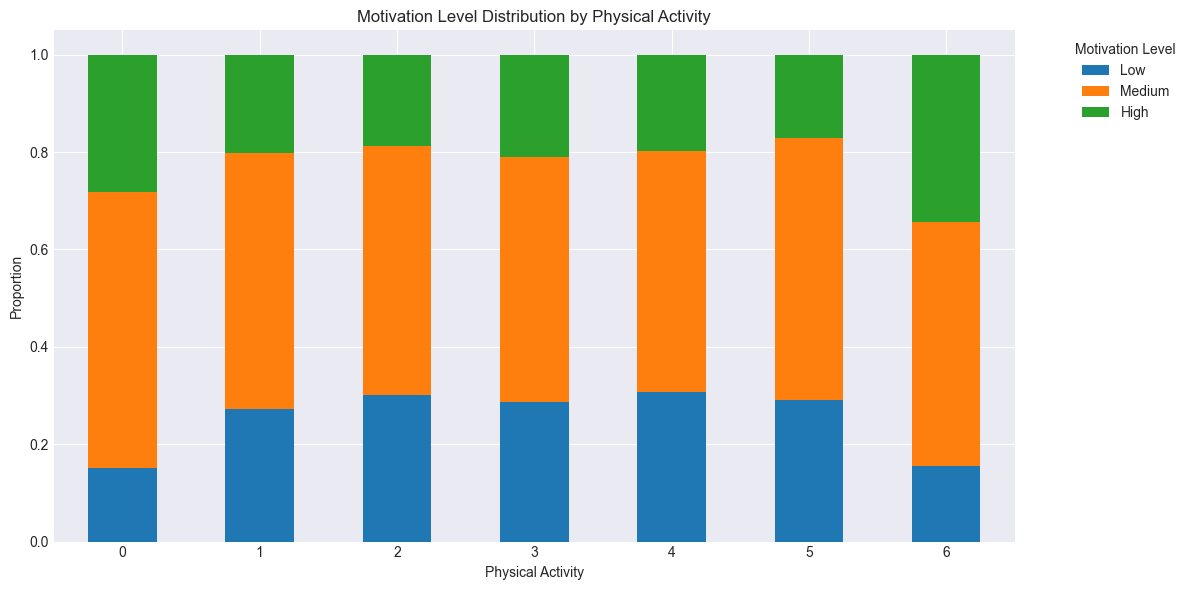

Motivation_Level,High,Low,Medium
Physical_Activity,,,
0,0.282609,0.152174,0.565217
1,0.201900,0.273159,0.524941
2,0.188076,0.301168,0.510756
3,0.209037,0.287623,0.503340
4,0.196825,0.306667,0.496508
5,0.171745,0.290859,0.537396
6,0.343750,0.156250,0.500000


In [16]:
# sns.countplot(data=df,x='Physical_Activity',hue='Motivation_Level',hue_order=['Low', 'Medium', 'High'])

ct = pd.crosstab(df['Physical_Activity'], df['Motivation_Level'], normalize='index')                                    
ct[['Low', 'Medium', 'High']].plot(kind='bar', stacked=True,figsize=(12, 6),rot=0)         

plt.title('Motivation Level Distribution by Physical Activity')                                                         
plt.xlabel('Physical Activity')                                                                                         
plt.ylabel('Proportion')                                                                                                
plt.legend(title='Motivation Level', bbox_to_anchor=(1.05, 1), loc='upper left')                                        
plt.tight_layout()                                      
                                                   
plt.show()         

ct # to show what crosstab do 

From the stacked bar chart, the proportions of Low, Medium, and High motivation look nearly identical across all physical activity levels. No visible pattern.

`H0` There is no association between Physical Activity and Motivation Level

`H1` There is an association between Physical Activity and Motivation Level

In [17]:
                                                                                                              
contingency = pd.crosstab(df['Physical_Activity'], df['Motivation_Level'])
chi2, p, dof, expected = chi2_contingency(contingency)                                                                  
v = association(contingency, method='cramer', correction=True)
                                                                                                                          
print(f"Chi2 = {chi2:.2f}, p = {p:.4f}")    
print(f"Cramer's V = {v:.4f}")                                                                                          
print("Significant!" if p < ALPHA else "Not enough evidence We do not reject H0")   

Chi2 = 17.65, p = 0.1268
Cramer's V = 0.0365
Not enough evidence We do not reject H0


**Insight**: No association between Physical Activity and Motivation Level (p=0.13, Cramér's V=0.04). Physical activity does not influence motivation levels.

---

## Q6: Do Higher attendance lead to better exam scores?


Text(0, 0.5, 'Exam Score')

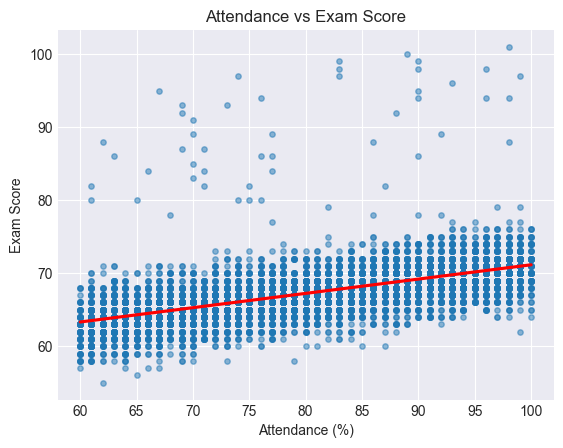

In [18]:
sns.regplot(data=df, x='Attendance', y='Exam_Score', scatter_kws={'s': 15, 'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')

My interpretation for this line scatter plot is that there is a positive correlation between the Attendance rate and exam scores and we will check that using statistical tests


`H0` There is no relationship between Attendance and Exam Scores

`H1` There is an relationship between Attendance and Exam Scores

In [19]:
r,p = stats.pearsonr(df['Attendance'],y=df['Exam_Score'])

print(f'r={r}\nP-value: {p:.10f}')
if p < ALPHA:
    print(f'We Reject H0: There is relationship between Attendance and Exam scores')
else:
    print("We do not reject H0: There is no relationship between Attendance and Exam scores")
    


r=0.5810718633120642
P-value: 0.0000000000
We Reject H0: There is relationship between Attendance and Exam scores


**Insight:** Based on the data there is a positive correlation between `Attendance` and `Exam_Score` with `r=0.58` so if the student attends more classes his exam score should rise.

> thing to note here this is the best `r` values we got with `r=0.58`

---

## Q7: Does internet access affect exam scores?

Text(0, 0.5, 'Exam Score')

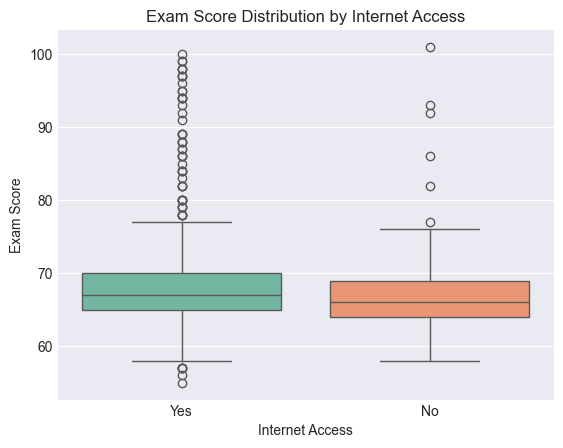

In [20]:
sns.boxplot(data=df, x='Internet_Access', y='Exam_Score', hue='Internet_Access', palette='Set2', legend=False)
plt.title('Exam Score Distribution by Internet Access')
plt.xlabel('Internet Access')
plt.ylabel('Exam Score')

From the boxplot the two groups look very similar, but students with internet access might have a slightly higher median

`H0` There is no difference in exam scores between students with and without internet access

`H1` There is a difference in exam scores between students with and without internet access

In [21]:
yes_int = df[df['Internet_Access'] == 'Yes']['Exam_Score']
no_int = df[df['Internet_Access'] == 'No']['Exam_Score']

t, p = stats.ttest_ind(yes_int, no_int)

print(f"t = {t:.2f}, p = {p:.7f}")
print(f"Yes: {yes_int.mean():.2f}, No: {no_int.mean():.2f}")
print("significant! we reject H0" if p < ALPHA else "not enough evidence, We fail to reject H0")

t = 4.19, p = 0.0000284
Yes: 67.29, No: 66.54
significant! we reject H0


**Insight**: Internet access has a significant but small effect on exam scores (Yes: 67.29 vs No: 66.54). Students with internet score about 0.75 points higher.

---

# Summary & Next Steps

## Key Findings

1. **Attendance is the strongest predictor of exam scores** with a moderate positive correlation (r=0.58, p<0.05). Students who attend more classes tend to score higher.

2. **Study hours positively correlate with exam scores** with a moderate correlation (r=0.44, p<0.05). More study hours are associated with better performance.

3. **Parental involvement does not affect attendance**. No significant difference in attendance across Low, Medium, and High parental involvement groups (Tukey HSD, p>0.05).

4. **Sleep hours and study hours are independent** with a near-zero correlation (r=0.01, p=0.37). Students who sleep less do not study more.

5. **Teacher quality has statistically significant but practically negligible impact**. High-quality teachers' students scored only ~1 point more than Low-quality teachers' students, suggesting other factors matter more.

6. **Physical activity does not influence motivation**. No association found (Chi-square p=0.13, Cramér's V=0.04). Motivation levels are evenly distributed across all physical activity levels.

7. **Internet access has a small but significant effect on exam scores**. Students with internet access scored 0.75 points higher on average (t-test, p<0.05), a statistically significant but practically small difference.

## Next Steps

- we can Build a predictive model (like a linear regression or decision tree) to quantify the combined effect of Attendance and Hours Studied on Exam Scores.

- Explore the remaining unused features (example: Family_Income, Previous_Scores, Learning_Disabilities) for additional insights.